/home/e12217676/miniconda/envs/protoattn/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Current Python version 3.10 is below the recommended 3.11 version. It is recommended to upgrade to Python 3.11 or higher for the best experience.
torch.compile is not available in Python 3.10, using identity decorator instead


📄 Loaded PPL for ProtoAttn from final_val_ppl.txt: 30.0265
🔎 ProtoAttn: saved=30.0265
tie_word_embeddings: True
is same object: True
same storage: True
📄 Loaded PPL for LLaMA from final_val_ppl.txt: 26.2062
📂 Loading pre-tokenized data from val.npz
✅ Loaded 12,466,354 tokens from 18,015 documents
🔎 LLaMA: saved=26.2062, recomputed=26.2096, diff=0.0034
📄 Loaded PPL for Mamba from final_val_ppl.txt: 26.8997
🔎 Mamba: saved=26.8997


/home/e12217676/miniconda/envs/protoattn/lib/python3.10/site-packages/fla/modules/convolution.py:837: UserWarning: The `backend` parameter is set to `cuda`, but `causal_conv1d_fn` is not available. Switching to the Triton implementation instead. Consider installing `causal_conv1d` to enable the CUDA backend.
  warnings.warn(


[inject_deltanet_dropout] attn-out wrapped: 12 layers | mlp-out wrapped: 12 layers | mlp-intermediate wrapped: 12 layers
📄 Loaded PPL for Deltanet from final_val_ppl.txt: 32.0855
🔎 Deltanet: saved=32.0855


### === Robustness evaluation on the full benchmark (3500 pairs total, 7 slices) ===


/home/e12217676/prototype_attention/robustness/runner.py:61: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat(valid_summaries, ignore_index=True)


📄 Saved LaTeX (JS-only) table with bold best scores to results_full/robustness_summary_table.tex


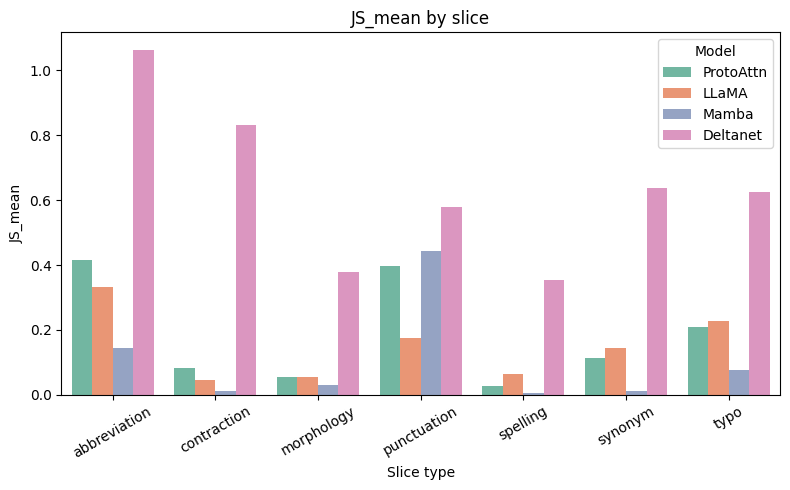

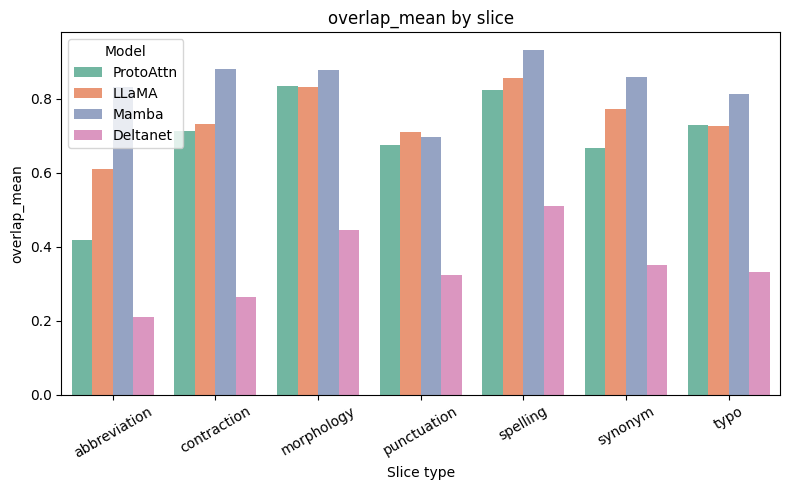

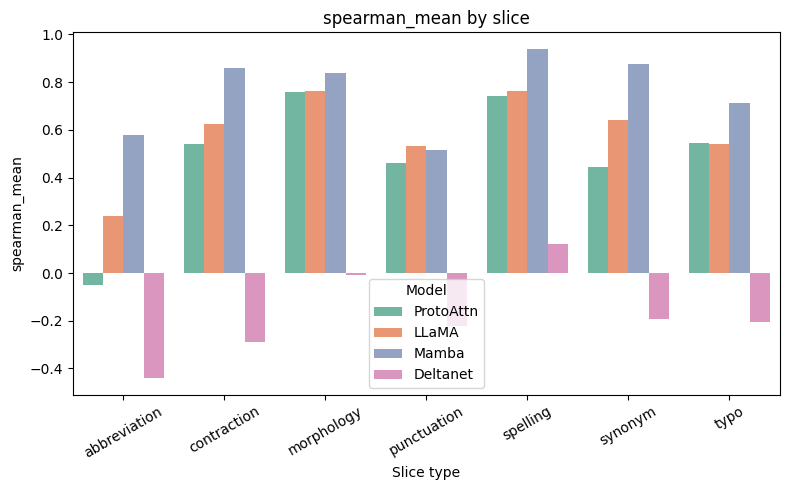


=== Slice-level JS divergence summary ===
model         Deltanet     LLaMA     Mamba  ProtoAttn
slice                                                
abbreviation  1.064231  0.332544  0.144146   0.416608
contraction   0.830997  0.044879  0.010426   0.082258
morphology    0.378451  0.054213  0.030811   0.054217
punctuation   0.580196  0.173999  0.442759   0.398199
spelling      0.354426  0.063446  0.005357   0.025950
synonym       0.636455  0.144992  0.013020   0.113240
typo          0.625949  0.226901  0.076057   0.207399

📄 Full CSV with all metrics saved in results_full/robustness_summary_table.csv
📄 LaTeX JS-only table saved in results_full/robustness_summary_table.tex


In [1]:
##### === Setup ===
import sys, os
sys.path.append(os.path.abspath(".."))

from robustness.models import load_model, ModelSpec
from robustness.tasks import load_benchmark
from robustness.runner import run_eval, make_report
from collections import defaultdict
import pandas as pd

# --- Paths to checkpoints ---
proto_path    = "ProtoAttn_large_FineWeb_scheduler"
llama_path    = "LLaMa_large_FineWeb_scheduler"
mamba_path    = "mamba1_large_fineweb"
deltanet_path = "deltanet_large_fineweb"

# --- Load models ---
models = [
    load_model(ModelSpec(name="ProtoAttn", kind="protoattn", path=proto_path),
               compute_full_ppl=False),
    load_model(ModelSpec(name="LLaMA", kind="llama", path=llama_path),
               compute_full_ppl=True, force_recompute=True),
    load_model(ModelSpec(name="Mamba", kind="mamba", path=mamba_path),
               compute_full_ppl=False),
    load_model(ModelSpec(name="Deltanet", kind="deltanet", path=deltanet_path),
               compute_full_ppl=False),
]

# ======================================================
# Robustness evaluation on the full benchmark
# ======================================================
pairs = load_benchmark(
    "perturbation",
    path="perturbation_dataset/perturbation_benchmark_clean.jsonl"
)

grouped = defaultdict(list)
for slice_name, a, b in pairs:
    grouped[slice_name].append((a, b))

print(f"\n\n### === Robustness evaluation on the full benchmark "
      f"({len(pairs)} pairs total, {len(grouped)} slices) ===")

# --- Run evaluation ---
summary = run_eval(models, pairs, names=[m.name for m in models])

# --- Generate report ---
report = make_report(summary, outdir="results_full")

print("\n=== Slice-level JS divergence summary ===")
print(report.to_string())
print("\n Full CSV with all metrics saved in results_full/robustness_summary_table.csv")
print("LaTeX JS-only table saved in results_full/robustness_summary_table.tex")